

# Phân cụm K-Means 

Thời lượng ước tính: **25** phút

## Mục tiêu

Sau khi hoàn thành lab này, bạn sẽ có thể:

*   Sử dụng phân cụm K-Means của scikit-learn để phân cụm dữ liệu


## Giới thiệu

In this notebook, you will learn how to use k-Means for customer segmentation. Có rất nhiều mô hình dành cho **phân cụm**. Trong notebook này, chúng tôi sẽ trình bày cho bạn một trong những mô hình đơn giản nhất. Mặc dù đơn giản nhưng **K-means** được sử dụng rộng rãi để phân cụm trong nhiều ứng dụng khoa học dữ liệu, và nó đặc biệt hữu ích nếu bạn cần nhanh chóng khám phá các insight từ **dữ liệu chưa được gắn nhãn**. Trong notebook này, bạn sẽ học cách sử dụng k-Means cho phân khúc khách hàng.

Một số ứng dụng thực tế của k-means:

*   Phân khúc khách hàng
*   Hiểu những gì mà khách truy cập của một trang web đang cố gắng đạt được
*   Nhận dạng mẫu
*   Học máy
*   Nén dữ liệu

Trong notebook này, chúng ta sẽ thực hành phân cụm k-means với 2 ví dụ:

*   k-means trên tập dữ liệu được tạo ngẫu nhiên
*   Sử dụng k-means để phân khúc khách hàng


<h1>Mục lục</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ul>
        <li><a href="https://#random_generated_dataset">k-Means trên tập dữ liệu được tạo ngẫu nhiên</a></li>
            <ol>
                <li><a href="https://#setting_up_K_means">Thiết lập K-Means</a></li>
                <li><a href="https://#creating_visual_plot">Tạo đồ thị trực quan</a></li>
            </ol>
        <p></p>
        <li><a href="https://#customer_segmentation_K_means">Phân khúc khách hàng với K-Means</a></li>
            <ol>
                <li><a href="https://#pre_processing">Tiền xử lý</a></li>
                <li><a href="https://#modeling">Lập mô hình</a></li>
                <li><a href="https://#insights">Insight</a></li>
            </ol>
    </ul>
</div>
<br>
<hr>


### Import thư viện

Trước tiên, hãy import các thư viện cần thiết.
Hãy chạy cả <b> %matplotlib inline </b> vì chúng ta sẽ vẽ biểu đồ trong phần này.


In [1]:
import random 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
%matplotlib inline

<h1 id="random_generated_dataset">k-Means trên tập dữ liệu được tạo ngẫu nhiên</h1>

Trước tiên, bạn hãy tự tạo tập dữ liệu cho lab này!


Trước tiên, chúng ta cần thiết lập random seed. Sử dụng hàm  <b> random.seed()</b> của numpy, trong đó seed được đặt thành 0.


In [2]:
np.random.seed(0)

Tiếp theo, chúng ta sẽ tạo <i>các cụm điểm ngẫu nhiên</i> bằng class <b> make_blobs </b>. Class <b> make_blobs </b> có thể có nhiều đầu vào, nhưng chúng ta sẽ sử dụng những đầu vào cụ thể sau: <br> <br> <b> <u> Đầu vào </u> </b>

<ul>
    <li> <b>n_samples</b>: Tổng số điểm chia đều cho các cụm. </li>
    <ul> <li> Giá trị sẽ là: 5000 </li> </ul>
    <li> <b>centers</b>: Số lượng tâm để tạo hoặc vị trí tâm cố định. </li>
    <ul> <li> Giá trị sẽ là: [[4, 4], [-2, -1], [2, -3],[1,1]] </li> </ul>
    <li> <b>cluster_std</b>: Độ lệch chuẩn của các cụm. </li>
    <ul> <li> Giá trị sẽ là: 0.9 </li> </ul>
</ul>
<br>
<b> <u> Đầu ra </u> </b>
<ul>
    <li> <b>X</b>: Mảng có shape [n_samples, n_features]. (Feature Matrix)</li>
    <ul> <li> Các mẫu đã tạo. </li> </ul> 
    <li> <b>y</b> Mảng có shape [n_samples]. (Response Vector)</li>
    <ul> <li> Các nhãn số nguyên với tư cách thành viên cụm của từng mẫu. </li> </ul>
</ul>


In [3]:
X, y = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], cluster_std=0.9)

Hiển thị biểu đồ phân tán của dữ liệu được tạo ngẫu nhiên.


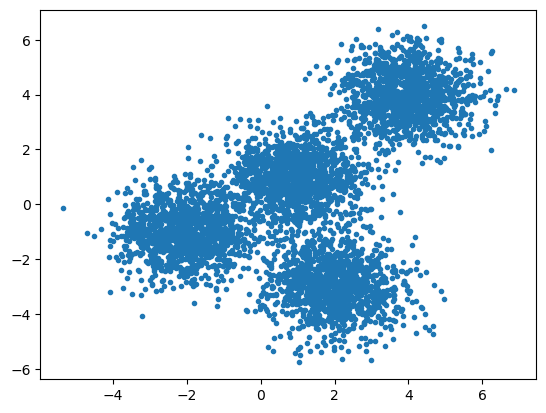

In [4]:
plt.scatter(X[:, 0], X[:, 1], marker='.')

<h2 id="setting_up_K_means">Thiết lập K-Means</h2>
Bây giờ chúng ta đã có dữ liệu ngẫu nhiên, hãy thiết lập Phân cụm K-Means.


KMeans class có nhiều tham số có thể được sử dụng, nhưng chúng ta sẽ sử dụng ba tham số sau:

<ul>
    <li> <b>init</b>: Phương thức khởi tạo của centroid.</li>
    <ul>
        <li> Giá trị sẽ là: "k-means++" </li>
        <li> k-means++: Chọn các tâm cụm ban đầu để phân cụm k-mean theo cách thông minh nhằm tăng tốc độ hội tụ.</li>
    </ul>
    <li> <b>n_clusters</b>: Số lượng cụm để hình thành cũng như số lượng centroid để tạo. </li>
    <ul> <li> Giá trị sẽ là: 4 (vì chúng ta có 4 tâm)</li> </ul>
    <li> <b>n_init</b>: Số lần thuật toán k-means sẽ chạy với các centroid seed khác nhau. Kết quả cuối cùng sẽ là đầu ra tốt nhất của n_init lần chạy liên tiếp theo quán tính. </li>
    <ul> <li> Giá trị sẽ là: 12 </li> </ul>
</ul>

Hãy khởi tạo KMeans với các tham số này, trong đó tham số đầu ra được gọi là <b>k_means.</b>.


In [5]:
k_means = KMeans(init = "k-means++", n_clusters = 4, n_init = 12)

Bây giờ, hãy khớp mô hình KMeans với ma trận đặc trưng mà chúng ta đã tạo ở trên - <b> X </b>.


In [6]:
k_means.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,12
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


Bây giờ, hãy lấy các nhãn cho từng điểm trong mô hình bằng thuộc tính <b> .labels\_ </b> của KMeans và lưu thành <b> k_means_labels </b>.


In [7]:
k_means_labels = k_means.labels_
k_means_labels

array([0, 3, 3, ..., 1, 0, 0], shape=(5000,), dtype=int32)

Chúng ta cũng sẽ lấy tọa độ của các tâm cụm bằng cách dùng <b> .cluster_centers\_ </b> của KMeans và lưu thành <b> k_means_cluster_centers </b>.


In [8]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[-2.03743147, -0.99782524],
       [ 3.97334234,  3.98758687],
       [ 0.96900523,  0.98370298],
       [ 1.99741008, -3.01666822]])

<h2 id="creating_visual_plot">Tạo biểu đồ trực quan</h2>

Bây giờ chúng ta đã có được dữ liệu ngẫu nhiên và khởi tạo mô hình KMeans, hãy vẽ và xem nó trông như thế nào!


Hãy đọc code và các chú thích để hiểu cách vẽ biểu đồ cho mô hình.


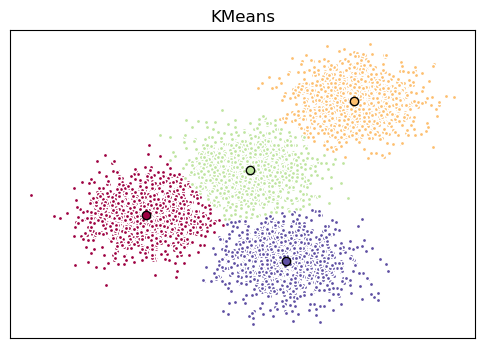

In [9]:
# Khởi tạo biểu đồ với các kích thước được chỉ định.
fig = plt.figure(figsize=(6, 4))

# colors sử dụng color map, điều này tạo ra một mảng gồm các màu dựa trên
# số lượng nhãn ở đó. Chúng ta sử dụng set(k_means_labels) để lấy
# các nhãn duy nhất.
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means_labels))))

# Tạo biểu đồ
ax = fig.add_subplot(1, 1, 1)

# Vòng lặp for vẽ các điểm dữ liệu và centroid.
# k sẽ dao động từ 0-3, khớp với các cụm khả dụng  
# của mỗi điểm dữ liệu. 
for k, col in zip(range(len([[4,4], [-2, -1], [2, -3], [1, 1]])), colors):

    # Tạo list tất cả các điểm dữ liệu, trong đó các điểm dữ liệu
    # trong cụm (chẳng hạn cụm 0) được gán nhãn là true, nếu không
    # sẽ được gán nhãn false.
    my_members = (k_means_labels == k)
    
    # Xác định centroid hoặc cluster center.
    cluster_center = k_means_cluster_centers[k]
    
    # Vẽ biểu đồ các điểm dữ liệu với color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')
    
    # Vẽ biểu đồ các centroid với màu được chỉ định, nhưng là với viền đậm hơn
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Tiêu đề của biểu đồ 
ax.set_title('KMeans')

# Xóa dấu tick trục x
ax.set_xticks(())

# Xóa dấu tick trục y
ax.set_yticks(())

# Hiển thị biểu đồ
plt.show()


## Luyện tập

Cố gắng phân cụm tập dữ liệu trên thành 3 cụm.
Lưu ý: không tạo lại dữ liệu, sử dụng cùng một tập dữ liệu như trên.


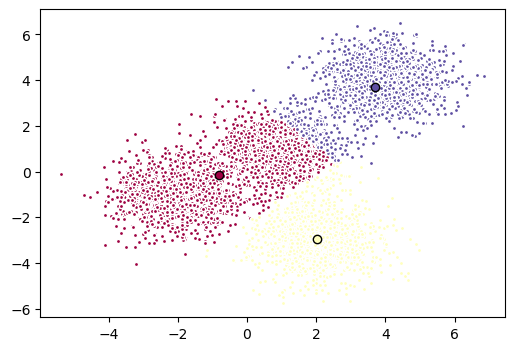

In [12]:
# nhập code ở đây
k_means = KMeans(init = "k-means++", n_clusters = 3, n_init = 12)
k_means.fit(X)


fig = plt.figure(figsize=(6, 4))

# colors sử dụng color map, điều này tạo ra một mảng gồm các màu dựa trên
# số lượng nhãn ở đó. Chúng ta sử dụng set(k_means_labels) để lấy
# các nhãn duy nhất.
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means.labels_))))

# Tạo biểu đồ
ax = fig.add_subplot(1, 1, 1)

for k, col in zip(range(len(k_means.cluster_centers_)), colors):
    my_members = (k_means.labels_ == k)
    cluster_center = k_means.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Hiển thị biểu đồ
plt.show()


<details><summary>Click vào đây để xem lời giải</summary>

```python
k_means3 = KMeans(init = "k-means++", n_clusters = 3, n_init = 12)
k_means3.fit(X)
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(k_means3.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means3.cluster_centers_)), colors):
    my_members = (k_means3.labels_ == k)
    cluster_center = k_means3.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.')
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()

```

</details>


<h1 id="customer_segmentation_K_means">Phân khúc khách hàng với K-Means</h1>

Hãy tưởng tượng là bạn có một tập dữ liệu khách hàng và bạn cần áp dụng phân khúc khách hàng trên dữ liệu lịch sử này. Bạn cần thực hành phân vùng cơ sở khách hàng thành các nhóm cá nhân có đặc điểm tương tự. Đây là một chiến lược quan trọng vì doanh nghiệp có thể nhắm mục tiêu đến các nhóm khách hàng cụ thể này và phân bổ hiệu quả các nguồn lực tiếp thị. Ví dụ: một nhóm có thể gồm những khách hàng có lợi nhuận cao và rủi ro thấp, nghĩa là có nhiều khả năng sẽ mua sản phẩm hoặc đăng ký dịch vụ hơn và nhiệm vụ kinh doanh là giữ chân những khách hàng đó; một nhóm khác có thể bao gồm khách hàng từ các tổ chức phi lợi nhuận,...

Hãy download tập dữ liệu. Chúng ta sẽ sử dụng **`!wget`** để download từ IBM Object Storage.



In [16]:
!wget -O Cust_Segmentation.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv

zsh:1: command not found: wget


### Load dữ liệu từ file CSV 

Trước khi có thể làm việc với dữ liệu, bạn phải sử dụng URL để lấy Cust_Segmentation.csv.


In [14]:
import pandas as pd
cust_df = pd.read_csv("Cust_Segmentation.csv")
cust_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Cust_Segmentation.csv'

<h2 id="pre_processing">Tiền xử lý</h2


Như bạn có thể thấy, **Address** trong tập dữ liệu này là một biến hạng mục. Thuật toán k-means không áp dụng trực tiếp cho các biến hạng mục vì hàm khoảng cách Euclide không thực sự có ý nghĩa đối với các biến rời rạc. Vì vậy, hãy bỏ đặc trưng này và chạy phân cụm.


In [ ]:
df = cust_df.drop('Address', axis=1)
df.head()

#### Chuẩn hóa trên độ lệch chuẩn

Bây giờ hãy chuẩn hóa tập dữ liệu. Nhưng tại sao chúng ta cần chuẩn hóa ngay từ đầu? Chuẩn hóa là một phương pháp thống kê giúp các thuật toán dựa trên toán học diễn giải đặc trưng có độ lớn khác nhau và phân bổ như nhau. Chúng ta sẽ sử dụng **StandardScaler()** để chuẩn hóa tập dữ liệu của mình.

In [ ]:
from sklearn.preprocessing import StandardScaler
X = df.values[:,1:]
X = np.nan_to_num(X)
Clus_dataSet = StandardScaler().fit_transform(X)
Clus_dataSet

<h2 id="modeling">Lập mô hình</h2>


Trong ví dụ (nếu chúng ta không có quyền truy cập vào thuật toán k-means), thì việc đoán rằng mỗi nhóm khách hàng sẽ có độ tuổi, thu nhập, trình độ học vấn nhất định cũng tương tự như nhiều bài test và thử nghiệm. Tuy nhiên, chúng ta có thể thực hiện tất cả quy trình này dễ dàng hơn nhiều bằng phân cụm K-mean.

Hãy áp dụng k-means trên tập dữ liệu của chúng ta và xem xét các nhãn cụm.


In [ ]:
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(X)
labels = k_means.labels_
print(labels)

<h2 id="insights">Insight</h2>

Chúng ta gán nhãn cho từng hàng trong dataframe.


In [ ]:
df["Clus_km"] = labels
df.head(5)

Chúng ta có thể dễ dàng kiểm tra các giá trị centroid bằng cách tính trung bình các đặc trưng trong mỗi cụm.


In [ ]:
df.groupby('Clus_km').mean()

Bây giờ, hãy xem xét phân bổ khách hàng dựa trên độ tuổi và thu nhập của họ:


In [ ]:
area = np.pi * ( X[:, 1])**2  
plt.scatter(X[:, 0], X[:, 3], s=area, c=labels.astype(np.float), alpha=0.5)
plt.xlabel('Age', fontsize=18)
plt.ylabel('Income', fontsize=16)

plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D 
fig = plt.figure(1, figsize=(8, 6))
plt.clf()
ax = Axes3D(fig, rect=[0, 0, .95, 1], elev=48, azim=134)

plt.cla()
# plt.ylabel('Age', fontsize=18)
# plt.xlabel('Income', fontsize=16)
# plt.zlabel('Education', fontsize=16)
ax.set_xlabel('Education')
ax.set_ylabel('Age')
ax.set_zlabel('Income')

ax.scatter(X[:, 1], X[:, 0], X[:, 3], c= labels.astype(np.float))


k-means sẽ phân vùng khách hàng thành các nhóm loại trừ lẫn nhau, chẳng hạn như thành 3 cụm. Các khách hàng trong mỗi cụm tương tự nhau về mặt nhân khẩu học. Bây giờ, chúng ta có thể tạo một hồ sơ cho từng nhóm, xem xét các đặc điểm chung của từng cụm. Ví dụ, 3 cụm có thể là:

*   AFFLUENT, EDUCATED VÀ OLD AGED
*   MIDDLE AGED VÀ MIDDLE INCOME
*   YOUNG VÀ LOW INCOME
